In [39]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

## Simulate wave equation

In [40]:
# initialise variables
wave_dict = {'c':1.0,
             'Lt':5.0,
             'Lx':1.0, 
             'Ly':1.0,
             'dx':0.01, 
             'dy':0.01,
             'CFL':0.9,
             'bc_type':'neumann',
            }

init_dict = {'x_c':0.25,
             'y_c':0.5,
             'width':np.sqrt(0.005),
             'amplitude':1.0}

In [41]:
# spatial discretisation
Nx, Ny = int(wave_dict['Lx'] / wave_dict['dx']), int(wave_dict['Ly'] / wave_dict['dy']) # number of x and y points
x = np.linspace(0, wave_dict['Lx'], Nx + 1) # array of x values
y = np.linspace(0, wave_dict['Ly'], Ny + 1) # array of y values
X, Y = np.meshgrid(x, y, indexing='ij') # mesh grid

# temporal discretisation
dt = wave_dict['CFL'] * min(wave_dict['dx'], wave_dict['dy']) / wave_dict['c'] / np.sqrt(2) # root 2 factor for stability criteria
Nt = int(wave_dict['Lt'] / dt)
T = np.linspace(0, wave_dict['Lt'], Nt + 1)

In [42]:
# function to define the initial condition
# gaussian pule
gaussian_dict = {'x_c': 0.25,
                 'y_c': 0.5,
                 'width': np.sqrt(0.005),
                 'amplitude': 1.0}

# converts inputs into arrays
x_c = np.atleast_1d(gaussian_dict['x_c'])
y_c = np.atleast_1d(gaussian_dict['y_c'])
width = np.atleast_1d(gaussian_dict['width'])
amplitude = np.atleast_1d(gaussian_dict['amplitude'])

u0 = np.zeros_like(X, dtype=float)
for xx_c, yy_c, w, a in zip(x_c, y_c, width, amplitude):
    u0 += a * np.exp(-((X - xx_c) ** 2 + (Y - yy_c) ** 2) / (2 * w**2))

In [43]:
# boundary conditions
def apply_bc(U):
    if wave_dict['bc_type'] == 'dirichlet':
        U[0, :] = 0
        U[-1, :] = 0
        U[:, 0] = 0
        U[:, -1] = 0
    elif wave_dict['bc_type'] == 'neumann':
        U[0, :] = U[1, :]
        U[-1, :] = U[-2, :]
        U[:, 0] = U[:, 1]
        U[:, -1] = U[:, -2]
    elif wave_dict['bc_type'] == 'periodic':
        U[0, :] = U[-2, :]
        U[-1, :] = U[1, :]
        U[:, 0] = U[:, -2]
        U[:, -1] = U[:, 1]
    return U

In [48]:
# main solver
U = np.zeros((Nt + 1, Nx + 1, Ny + 1)) # solution array
U[0] = u0

# Pre-factors
alpha = (wave_dict['c'] * dt) ** 2

# First time step
Lap0 = (
    (U[0, 2:, 1:-1] - 2 * U[0, 1:-1, 1:-1] + U[0, :-2, 1:-1]) / wave_dict['dx'] ** 2
    + (U[0, 1:-1, 2:] - 2 * U[0, 1:-1, 1:-1] + U[0, 1:-1, :-2]) / wave_dict['dy'] ** 2
)
U[1, 1:-1, 1:-1] = (
    U[0, 1:-1, 1:-1]
    + 0.5 * alpha * Lap0
)
U[1] = apply_bc(U[1])

# Assuming no damping and du0_dt == 0
for n in range(1, Nt):
    # Laplacian
    Lap = (
        (U[n, 2:, 1:-1] - 2 * U[n, 1:-1, 1:-1] + U[n, :-2, 1:-1]) / wave_dict['dx'] ** 2
        + (U[n, 1:-1, 2:] - 2 * U[n, 1:-1, 1:-1] + U[n, 1:-1, :-2]) / wave_dict['dy'] ** 2
    )
    U[n + 1, 1:-1, 1:-1] = (
        2 * U[n, 1:-1, 1:-1]
        - U[n - 1, 1:-1, 1:-1]
        + alpha * Lap
    )
    U[n + 1] = apply_bc(U[n + 1])

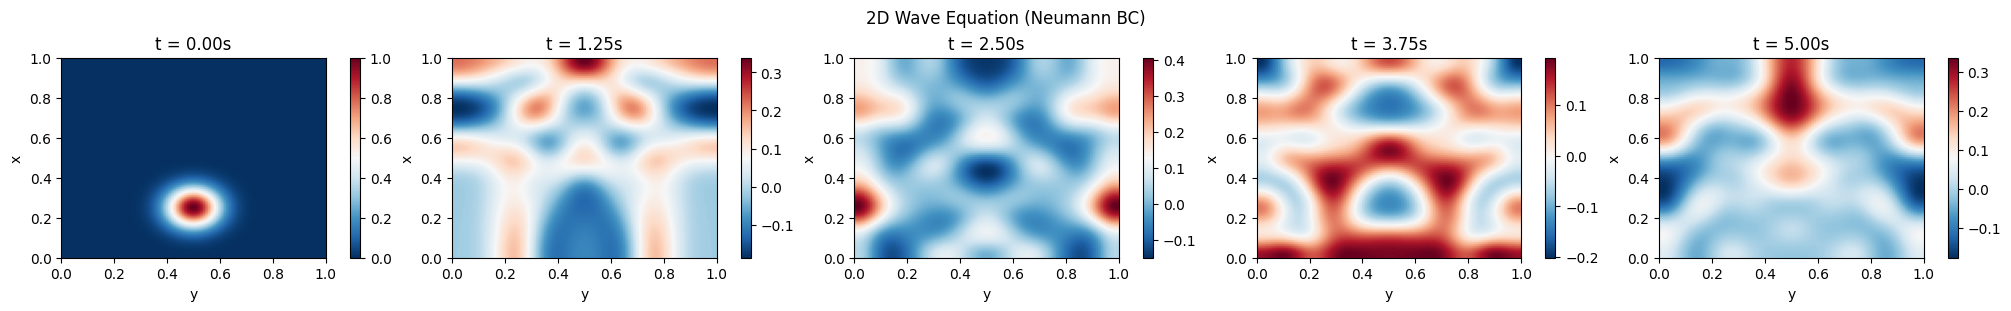

In [49]:
NT = len(U)

n_plots = 5
fig, axes = plt.subplots(1, n_plots, figsize=(20, 3), constrained_layout=True)
k_frames = np.linspace(0, NT-1, n_plots, dtype=int)

for ax, k in zip(axes, k_frames):
    cs = ax.imshow(U[k], origin='lower', extent=[0, wave_dict['Ly'], 0,  wave_dict['Lx']], cmap='RdBu_r', aspect='auto')
    ax.set_title(f"t = {T[k]:.2f}s")
    fig.colorbar(cs, ax=ax, location='right')
    ax.set_xlabel("y")
    ax.set_ylabel("x")

fig.suptitle(f"2D Wave Equation ({wave_dict['bc_type'].capitalize()} BC)")
plt.show()